In [43]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py

In [44]:
#DATA - DISTRIBUTED IN Z
#Importing Model Data
check=False
dir2='/home/air673/koa_scratch/'
data=xr.open_dataset(dir2+'cm1out1.nc') 
parcel=xr.open_dataset(dir2+'cm1out_pdata1.nc') 

In [45]:
# #DATA - DISTRIBUTED IN Z
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out2.nc') 
# parcel=xr.open_dataset(dir2+'cm1out_pdata2.nc') 

In [46]:
p_slice=slice(0,1000000)
z = parcel['z'].isel(time=0).data[p_slice]

Text(0.5, 1.0, 'Parcel Distribution by Height Level')

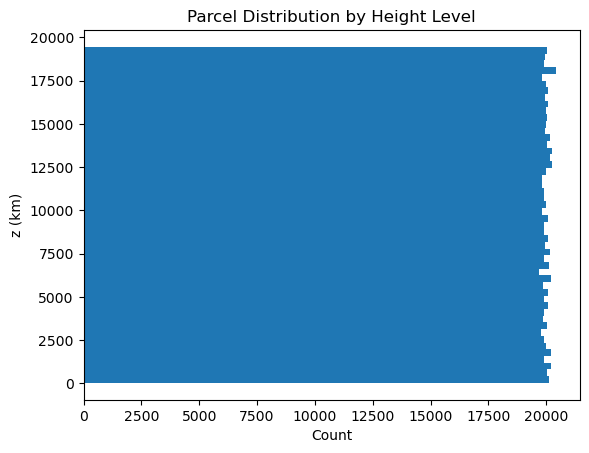

In [47]:
#PLOT OF LAGRANGIAN Z

counts, bin_edges, _ = plt.hist(z, bins=50, orientation='horizontal')
plt.ylabel('z (km)')
plt.xlabel('Count')
plt.title('Parcel Distribution by Height Level')
#max is 34 m, what?????

In [48]:
# plt.hist(zf[which_zh], weights=1/dz[which_zh], bins=50,orientation='horizontal');


In [49]:
# zf

In [50]:
# cond1=z<62
# np.where(cond1)[0].shape

In [51]:
# cond1=z>62
# cond2=z<155.89
# np.where(cond1&cond2)[0].shape

In [52]:
counts

array([20128., 20020., 20188., 19887., 20220., 19973., 19915., 19781.,
       20016., 19858., 19906., 20056., 19903., 20060., 19852., 20187.,
       19679., 20121., 19899., 20182., 19962., 20072., 19894., 19918.,
       20085., 19829., 19972., 19909., 19913., 19824., 19833., 20008.,
       20251., 20157., 20234., 20035., 20164., 19962., 19975., 20012.,
       19988., 20057., 19941., 20087., 19976., 19806., 20424., 19923.,
       19934., 20024.])

In [53]:
#LETS COUNT NUMBER IN EACH GRID BOX
#WHAT ARE THE MODEL Z-LEVELS
zh=data['zh'].values*1000; 
zf=data['zf'].values*1000; which_zh=np.clip(np.searchsorted(zf,z)-1,0,None)

which_zh

array([30, 19, 28, ..., 29, 32, 10])

In [54]:
print(zf)

np.searchsorted(zf,20001)-1

[    0.          62.000004   155.89336    281.68002    439.36002
   628.9334     850.40015   1103.7603    1389.0134    1706.1602
  2055.2004    2436.1333    2848.9604    3293.6804    3770.2937
  4278.8003    4819.201     5391.494     5995.6797    6631.761
  7299.734     7999.6006    8731.361     9495.015    10290.561
 11118.001    11977.335    12868.561    13791.683    14746.694
 15733.602    16752.402    17803.096    18885.682    20000.162   ]


34

[  62.000004   93.89336   125.78667   157.68      189.5734    221.46674
  253.3601    285.25317   317.14673   349.04028   380.93286   412.82715
  444.71997   476.61328   508.5066    540.4009    572.29297   604.18555
  636.08154   667.97266   699.8667    731.76074   763.6533    795.5459
  827.4404    859.334     891.2256    923.1221    955.0117    986.9072
 1018.8008   1050.6934   1082.5859   1114.4805  ]


Text(0.5, 1.0, 'dz = zf[1:] - zf[:-1]')

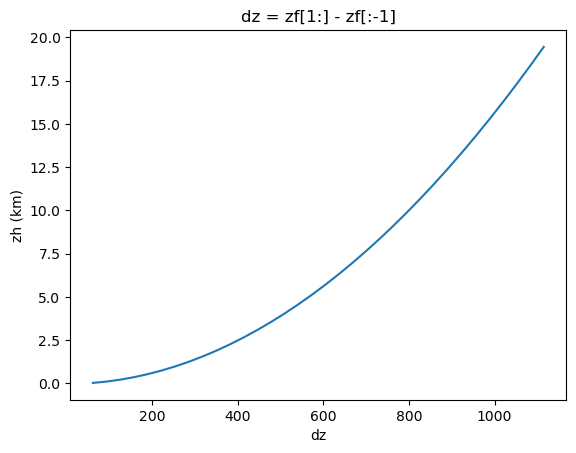

In [55]:
dz = zf[1:] - zf[:-1]
# dz=np.zeros([len(np.arange(len(zf)-1))])
# for k in range(len(dz)):
#     dz[k]=zf[k+1]-zf[k]
print(dz)
plt.plot(dz,data['zh'])
plt.ylabel('zh (km)');plt.xlabel('dz')
plt.title('dz = zf[1:] - zf[:-1]')

In [56]:
#LETS TRY MANUALLY BINNING
#MAKE PROFILE ARRAY
profile=np.zeros((len(zh),2))
profile[:,1]=zh

#BINNING
for z_ind in np.arange(len(data['zh'])):
    # count=len(np.where(which_zh==z_ind)[0])
    count = np.sum(which_zh == z_ind)

    profile[z_ind,0]=count
#dividing by dz
profile[:,0]/=dz  

Text(0.5, 1.0, 'dz = zf[1:] - zf[:-1]')

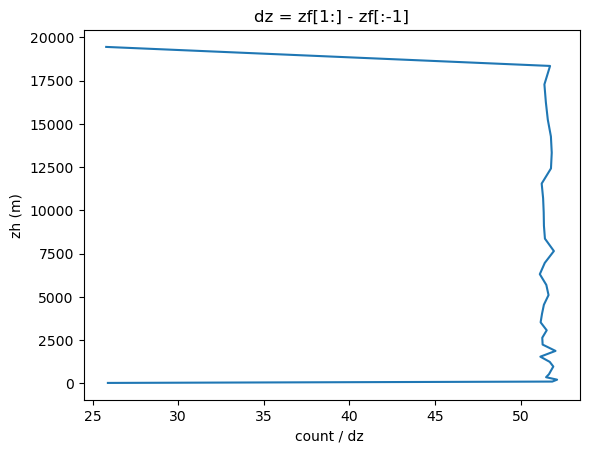

In [57]:
plt.plot(profile[:,0],profile[:,1])
plt.ylabel('zh (m)'); plt.xlabel('count / dz ')
plt.title('dz = zf[1:] - zf[:-1]')

In [58]:
dz

array([  62.000004,   93.89336 ,  125.78667 ,  157.68    ,  189.5734  ,
        221.46674 ,  253.3601  ,  285.25317 ,  317.14673 ,  349.04028 ,
        380.93286 ,  412.82715 ,  444.71997 ,  476.61328 ,  508.5066  ,
        540.4009  ,  572.29297 ,  604.18555 ,  636.08154 ,  667.97266 ,
        699.8667  ,  731.76074 ,  763.6533  ,  795.5459  ,  827.4404  ,
        859.334   ,  891.2256  ,  923.1221  ,  955.0117  ,  986.9072  ,
       1018.8008  , 1050.6934  , 1082.5859  , 1114.4805  ], dtype=float32)

In [59]:
1605/62
4848/93

52.12903225806452

In [60]:
dz

array([  62.000004,   93.89336 ,  125.78667 ,  157.68    ,  189.5734  ,
        221.46674 ,  253.3601  ,  285.25317 ,  317.14673 ,  349.04028 ,
        380.93286 ,  412.82715 ,  444.71997 ,  476.61328 ,  508.5066  ,
        540.4009  ,  572.29297 ,  604.18555 ,  636.08154 ,  667.97266 ,
        699.8667  ,  731.76074 ,  763.6533  ,  795.5459  ,  827.4404  ,
        859.334   ,  891.2256  ,  923.1221  ,  955.0117  ,  986.9072  ,
       1018.8008  , 1050.6934  , 1082.5859  , 1114.4805  ], dtype=float32)

In [61]:
#PLOTTING IN PRESSURE COORDINATE

Text(0, 0.5, 'zf (m)')

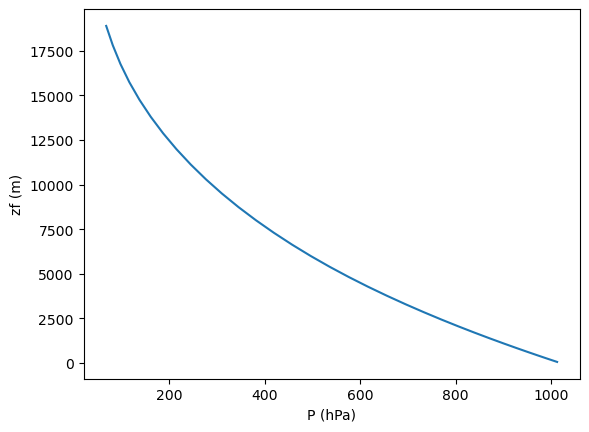

In [62]:
#PLOTTING P WITH HEIGHT
# P=data['prs'].isel(time=0,xh=0,yh=0).interp(zh=data['zf']).data/100
P=data['prs'].isel(time=0).mean(dim=('xh','yh')).interp(zh=data['zf']).data/100

plt.plot(P,data['zf']*1000)
plt.xlabel('P (hPa)');plt.ylabel('zf (m)')

In [63]:
P

array([        nan, 1011.99524 , 1001.4403  ,  987.4228  ,  970.05786 ,
        949.4857  ,  925.8682  ,  899.4023  ,  870.30493 ,  838.826   ,
        805.2534  ,  769.88226 ,  732.9843  ,  694.8314  ,  655.7371  ,
        616.02466 ,  576.0234  ,  536.0769  ,  496.48578 ,  457.4706  ,
        419.1925  ,  381.79913 ,  345.51364 ,  310.59796 ,  277.228   ,
        245.52295 ,  215.61293 ,  187.65813 ,  161.78944 ,  138.13934 ,
        116.927795,   98.3373  ,   82.27374 ,   68.5143  ,         nan],
      dtype=float32)

[       nan -10.554932 -14.017517 -17.36493  -20.572144 -23.617493
 -26.465942 -29.097351 -31.478943 -33.57257  -35.371155 -36.89795
 -38.152893 -39.0943   -39.712463 -40.00128  -39.946472 -39.591125
 -39.015167 -38.278107 -37.39337  -36.285492 -34.91568  -33.369965
 -31.705048 -29.910019 -27.954803 -25.868683 -23.6501   -21.211548
 -18.590492 -16.06356  -13.759445        nan]


Text(0.5, 1.0, 'dP = P[1:] - P[:-1]')

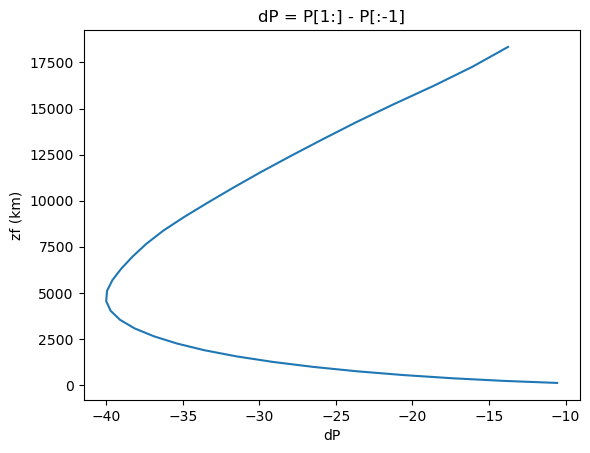

In [64]:
dP = P[1:] - P[:-1]
print(dP)

plt.plot(dP,zh)
plt.ylabel('zf (km)');plt.xlabel('dP')
plt.title('dP = P[1:] - P[:-1]')

In [65]:
#LETS COUNT NUMBER IN EACH GRID BOX
#WHAT ARE THE MODEL Z-LEVELS

In [66]:
#SOMETHING IS WRONG HERE 
#LETS TRY MANUALLY BINNING


#MAKE PROFILE ARRAY
profile=np.zeros((len(zh),2))
profile[:,1]=data['prs'].isel(time=0,xh=0,yh=0).data/100

#BINNING
for z_ind in np.arange(len(data['zh'])):
    count=len(np.where(which_zh==z_ind)[0])

    profile[z_ind,0]=+count
profile[:,0]/=dP

In [67]:
dP

array([       nan, -10.554932, -14.017517, -17.36493 , -20.572144,
       -23.617493, -26.465942, -29.097351, -31.478943, -33.57257 ,
       -35.371155, -36.89795 , -38.152893, -39.0943  , -39.712463,
       -40.00128 , -39.946472, -39.591125, -39.015167, -38.278107,
       -37.39337 , -36.285492, -34.91568 , -33.369965, -31.705048,
       -29.910019, -27.954803, -25.868683, -23.6501  , -21.211548,
       -18.590492, -16.06356 , -13.759445,        nan], dtype=float32)

Text(0.5, 1.0, 'dP = P[1:] - P[:-1]')

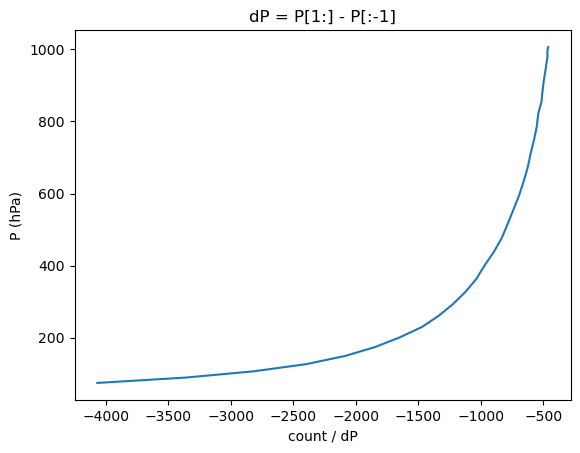

In [68]:
plt.plot(profile[:,0],profile[:,1])
plt.ylabel('P (hPa)'); plt.xlabel('count / dP')
plt.title('dP = P[1:] - P[:-1]')